# Vision Transformer para Classificação de Severidade de Acidentes

Este notebook implementa uma primeira versão end-to-end para classificação em nível de imagem usando o Car Accidents and Deformation Dataset (CADD).

Simplificação metodológica importante: os rótulos originais estão em formato YOLO para object detection. Para este baseline de classificação, cada imagem recebe um único rótulo usando:

`image_label = max(object_class_ids)`

Isso significa que o rótulo da imagem é tratado como a classe mais severa entre os objetos anotados naquela imagem. Essa é uma regra de agregação criada para este projeto, não um rótulo original do dataset.


## 1. Ambiente


In [1]:
import os
import re
import math
import random
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw, ImageFont

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

SEED = 42


def set_seed(seed=42):
    # Configura as principais fontes de aleatoriedade usadas neste notebook.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Versão do PyTorch: {torch.__version__}")
print(f"Versão do torchvision: {torchvision.__version__}")
print(f"CUDA disponível: {torch.cuda.is_available()}")
print(f"Versão do CUDA: {torch.version.cuda}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU disponível: {torch.cuda.get_device_name(0)}")


Versão do PyTorch: 2.11.0+cu128
Versão do torchvision: 0.26.0+cu128
CUDA disponível: True
Versão do CUDA: 12.8
Device: cuda
GPU disponível: Tesla T4


## 2. Configuração


In [14]:
# Altere este caminho depois de baixar e extrair o dataset no Colab.
# Estrutura esperada:
# DATASET_ROOT/images/train, DATASET_ROOT/images/val
# DATASET_ROOT/labels/train, DATASET_ROOT/labels/val
DATASET_ROOT = Path("/content/custom_dataset")

IMAGE_SIZE = 224
PATCH_SIZE = 16
NUM_CLASSES = 5

BATCH_SIZE = 32
NUM_EPOCHS = 20
BASELINE_EPOCHS = 5

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.05

VAL_SIZE = 0.20
NUM_WORKERS = 2

EMBED_DIM = 384
DEPTH = 6
NUM_HEADS = 6
MLP_RATIO = 4
DROPOUT = 0.1
ATTENTION_DROPOUT = 0.1

CLASS_NAMES = {
    0: "Sem Acidente",
    1: "Acidente Leve",
    2: "Acidente Moderado",
    3: "Acidente Severo",
    4: "Perda Total",
}

CHECKPOINT_PATH = Path("best_vit_cadd.pt")

### 2.1 Baixar e Extrair o Dataset do Kaggle

O erro `FileNotFoundError` indica que o dataset não está disponível no caminho `/content/dataset`. Precisamos baixar o dataset do Kaggle e extraí-lo para este local. Antes de executar as células abaixo, certifique-se de que suas credenciais da API do Kaggle estão configuradas nos segredos do Colab. Para fazer isso:

1. Clique no ícone de "Chave" (Secrets) no painel esquerdo do Colab.
2. Adicione duas novas variáveis secretas:
   - `KAGGLE_USERNAME`: Seu nome de usuário do Kaggle.
   - `KAGGLE_KEY`: Sua chave de API do Kaggle (gerada em sua conta Kaggle, na seção 'API').

In [4]:
# Instala a biblioteca Kaggle
!pip install kaggle --quiet

In [15]:
# Baixa o dataset do Kaggle e extrai para DATASET_ROOT
DATASET_ARCHIVE_NAME = 'car-accidents-and-deformation-datasetannotated'
!kaggle datasets download -d marslanarshad/{DATASET_ARCHIVE_NAME}
!unzip -q {DATASET_ARCHIVE_NAME}.zip -d {DATASET_ROOT.parent}

print(f"Dataset '{DATASET_ARCHIVE_NAME}' baixado e extraído para '{DATASET_ROOT.parent}'")

Dataset URL: https://www.kaggle.com/datasets/marslanarshad/car-accidents-and-deformation-datasetannotated
License(s): CC0-1.0
car-accidents-and-deformation-datasetannotated.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/custom_dataset/images/train/10_flip70.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/custom_dataset/images/train/11_flip70.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/custom_dataset/images/train/123.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace /content/custom_dataset/images/train/123.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Dataset 'car-accidents-and-deformation-datasetannotated' baixado e extraído para '/content'


## 3. Inspeção do Dataset


In [16]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def get_image_label(label_path):
    """Retorna o maior class id YOLO do arquivo, ou None para rótulos inutilizáveis."""
    label_path = Path(label_path)
    if not label_path.exists():
        warnings.warn(f"Arquivo de label ausente: {label_path}")
        return None

    text = label_path.read_text().strip()
    if not text:
        warnings.warn(f"Arquivo de label vazio: {label_path}")
        return None

    class_ids = []
    for line_number, line in enumerate(text.splitlines(), start=1):
        parts = line.split()
        if not parts:
            continue
        try:
            class_id = int(float(parts[0]))
        except ValueError:
            warnings.warn(f"Class id inválido em {label_path}:{line_number}: {parts[0]}")
            continue
        if 0 <= class_id < NUM_CLASSES:
            class_ids.append(class_id)
        else:
            warnings.warn(
                f"Class id fora do intervalo em {label_path}:{line_number}: {class_id}"
            )

    if not class_ids:
        warnings.warn(f"Nenhum class id válido encontrado em: {label_path}")
        return None

    # Regra de agregação deste projeto: a imagem recebe a classe mais severa anotada.
    return max(class_ids)


def list_images(dataset_root):
    dataset_root = Path(dataset_root)
    records = []
    problems = []

    for split in ["train", "val"]:
        image_dir = dataset_root / "images" / split
        label_dir = dataset_root / "labels" / split

        if not image_dir.exists():
            problems.append(f"Diretório de imagens ausente: {image_dir}")
            continue
        if not label_dir.exists():
            problems.append(f"Diretório de labels ausente: {label_dir}")
            continue

        for image_path in sorted(image_dir.iterdir()):
            if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue

            label_path = label_dir / f"{image_path.stem}.txt"
            label = get_image_label(label_path)
            if label is None:
                problems.append(f"Ignorando imagem com label inválido ou vazio: {image_path}")
                continue

            records.append(
                {
                    "image_path": image_path,
                    "label_path": label_path,
                    "label": label,
                    "original_split": split,
                    "filename": image_path.name,
                }
            )

    return records, problems


def inspect_expected_structure(dataset_root):
    dataset_root = Path(dataset_root)
    print(f"Raiz do dataset: {dataset_root.resolve() if dataset_root.exists() else dataset_root}")
    for relative_path in ["images/train", "images/val", "labels/train", "labels/val"]:
        path = dataset_root / relative_path
        print(f"{relative_path}: {'OK' if path.exists() else 'AUSENTE'}")


inspect_expected_structure(DATASET_ROOT)

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        "DATASET_ROOT não existe. Baixe/extraia o dataset do Kaggle e atualize DATASET_ROOT."
    )

all_records, dataset_problems = list_images(DATASET_ROOT)

print(f"Imagens válidas com label: {len(all_records)}")
print(f"Problemas encontrados: {len(dataset_problems)}")
for problem in dataset_problems[:20]:
    print(f"- {problem}")
if len(dataset_problems) > 20:
    print(f"... {len(dataset_problems) - 20} problemas adicionais omitidos")

inspection_df = pd.DataFrame(
    {
        "original_split": [r["original_split"] for r in all_records],
        "label": [r["label"] for r in all_records],
    }
)
display(inspection_df.groupby(["original_split", "label"]).size().unstack(fill_value=0))

Raiz do dataset: /content/custom_dataset
images/train: OK
images/val: OK
labels/train: OK
labels/val: OK
Imagens válidas com label: 1221
Problemas encontrados: 2
- Ignorando imagem com label inválido ou vazio: /content/custom_dataset/images/val/sbf_30_OIP_sb_30.jpg
- Ignorando imagem com label inválido ou vazio: /content/custom_dataset/images/val/sbf_70_OIP (2)_sb_100.jpg


/tmp/ipykernel_4858/3447086545.py:7: UserWarning: Arquivo de label ausente: /content/custom_dataset/labels/val/sbf_30_OIP_sb_30.txt
  warnings.warn(f"Arquivo de label ausente: {label_path}")
/tmp/ipykernel_4858/3447086545.py:7: UserWarning: Arquivo de label ausente: /content/custom_dataset/labels/val/sbf_70_OIP (2)_sb_100.txt
  warnings.warn(f"Arquivo de label ausente: {label_path}")


label,0,1,2,3,4
original_split,,,,,
train,46,250,283,148,250
val,19,54,48,55,68


In [17]:
# Inspeciona a estrutura de arquivos no diretório de extração para determinar o DATASET_ROOT correto.
!ls -F /content/car-accidents-and-deformation-datasetannotated/

ls: cannot access '/content/car-accidents-and-deformation-datasetannotated/': No such file or directory


In [13]:
# Lista o conteúdo do arquivo ZIP para verificar a estrutura interna
!unzip -l /content/{DATASET_ARCHIVE_NAME}.zip

Archive:  /content/car-accidents-and-deformation-datasetannotated.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
    28358  2025-07-23 20:36   custom_dataset/images/train/10_flip70.jpg
    42378  2025-07-23 20:36   custom_dataset/images/train/11_flip70.jpg
    10854  2025-07-23 20:36   custom_dataset/images/train/123.jpg
    14767  2025-07-23 20:36   custom_dataset/images/train/123_flip50.jpg
    14572  2025-07-23 20:36   custom_dataset/images/train/12_flip50.jpg
    28998  2025-07-23 20:36   custom_dataset/images/train/12_flip70.jpg
    25042  2025-07-23 20:36   custom_dataset/images/train/13_flip70.jpg
    39839  2025-07-23 20:36   custom_dataset/images/train/14_flip70.jpg
    16537  2025-07-23 20:36   custom_dataset/images/train/15_flip70.jpg
    38629  2025-07-23 20:36   custom_dataset/images/train/16_flip70.jpg
    53479  2025-07-23 20:36   custom_dataset/images/train/18_flip70.jpg
    20319  2025-07-23 20:36   custom_dataset/images/train/19_flip70.jpg
 

## 4. Split leakage-aware


In [18]:
AUG_SUFFIX_PATTERN = re.compile(
    r"(_flip\d*|_rotate\d*|_rot\d*|_aug\d*|_invert\d*)$",
    flags=re.IGNORECASE,
)


def get_image_group(filename):
    """Retorna um group id leakage-aware removendo sufixos conhecidos de augmentation."""
    stem = Path(filename).stem
    previous = None
    while previous != stem:
        previous = stem
        stem = AUG_SUFFIX_PATTERN.sub("", stem)
    return stem.lower()


for record in all_records:
    record["group"] = get_image_group(record["filename"])

# O split é feito por grupo, não por imagem, para evitar que augmentations relacionadas vazem.
group_to_records = defaultdict(list)
for record in all_records:
    group_to_records[record["group"]].append(record)

groups = sorted(group_to_records.keys())
print(f"Total de imagens válidas: {len(all_records)}")
print(f"Total de grupos após normalizar raízes de augmentation: {len(groups)}")

mixed_original_split_groups = [
    group
    for group, records in group_to_records.items()
    if len({r["original_split"] for r in records}) > 1
]
print(f"Grupos presentes no train e val originais: {len(mixed_original_split_groups)}")
print(mixed_original_split_groups[:20])

train_groups, val_groups = train_test_split(
    groups,
    test_size=VAL_SIZE,
    random_state=SEED,
    shuffle=True,
)

train_groups = set(train_groups)
val_groups = set(val_groups)

assert train_groups.isdisjoint(val_groups)

train_records = [r for r in all_records if r["group"] in train_groups]
val_records = [r for r in all_records if r["group"] in val_groups]

train_group_check = {r["group"] for r in train_records}
val_group_check = {r["group"] for r in val_records}
assert train_group_check.isdisjoint(val_group_check), "Leakage detectado: o mesmo grupo aparece nos dois splits"

print(f"Novos grupos de treino: {len(train_group_check)}")
print(f"Novos grupos de validação: {len(val_group_check)}")
print(f"Novas amostras de treino: {len(train_records)}")
print(f"Novas amostras de validação: {len(val_records)}")


Total de imagens válidas: 1221
Total de grupos após normalizar raízes de augmentation: 1016
Grupos presentes no train e val originais: 70
['11', '12', '13', '19', '21', '240_f_312098032_5srfits5rdumjt478vhjbbaj5wr4kduf', '240_f_384717123_ixvkshvhe9v0xfaah5ughb27l90yhbeg', '240_f_618729965_jbcjmgjadfbhgkpxqpg2ii9ytzegvypa', '26', '343', '43', 'car,accident', 'oip (8)', 'screenshot 2023-08-16 230456', 'screenshot 2023-08-16 230658', 'screenshot 2023-08-16 232615', 'screenshot 2023-08-16 233926', 'screenshot 2023-08-16 234118', 'screenshot 2023-08-16 234340', 'screenshot 2023-08-16 234607']
Novos grupos de treino: 812
Novos grupos de validação: 204
Novas amostras de treino: 980
Novas amostras de validação: 241


## 5. Dataset e DataLoaders


In [19]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

val_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)


class AccidentDataset(Dataset):
    def __init__(self, records, transform=None):
        self.records = list(records)
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        record = self.records[idx]
        image = Image.open(record["image_path"]).convert("RGB")
        label = int(record["label"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label


train_dataset = AccidentDataset(train_records, transform=train_transform)
val_dataset = AccidentDataset(val_records, transform=val_transform)

# pin_memory acelera a cópia CPU -> GPU quando CUDA está disponível.
pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

images, labels = next(iter(train_loader))
print(f"Batch de imagens: {images.shape}")
print(f"Batch de labels: {labels.shape}")


Batch de imagens: torch.Size([32, 3, 224, 224])
Batch de labels: torch.Size([32])


## 6. Distribuição das Classes


In [20]:
def print_class_distribution(records, title):
    counts = Counter(int(r["label"]) for r in records)
    print(title)
    for class_id in range(NUM_CLASSES):
        print(f"Classe {class_id} ({CLASS_NAMES[class_id]}): {counts.get(class_id, 0)}")
    return counts


train_counts = print_class_distribution(train_records, "Distribuição do treino")
val_counts = print_class_distribution(val_records, "\nDistribuição da validação")


def make_class_weights(records, num_classes):
    counts = Counter(int(r["label"]) for r in records)
    total = sum(counts.values())
    weights = []
    for class_id in range(num_classes):
        count = counts.get(class_id, 0)
        if count == 0:
            warnings.warn(f"Classe {class_id} não tem amostras no treino; usando peso 0.")
            weights.append(0.0)
        else:
            weights.append(total / (num_classes * count))
    return torch.tensor(weights, dtype=torch.float32)


class_weights = make_class_weights(train_records, NUM_CLASSES).to(device)
print(f"Pesos de classe: {class_weights.detach().cpu().numpy()}")

criterion = nn.CrossEntropyLoss(weight=class_weights)


Distribuição do treino
Classe 0 (Sem Acidente): 48
Classe 1 (Acidente Leve): 245
Classe 2 (Acidente Moderado): 253
Classe 3 (Acidente Severo): 163
Classe 4 (Perda Total): 271

Distribuição da validação
Classe 0 (Sem Acidente): 17
Classe 1 (Acidente Leve): 59
Classe 2 (Acidente Moderado): 78
Classe 3 (Acidente Severo): 40
Classe 4 (Perda Total): 47
Pesos de classe: [4.0833335  0.8        0.77470356 1.202454   0.72324723]


## Funções Compartilhadas de Treinamento e Avaliação


In [21]:
def autocast_context(enabled):
    if hasattr(torch, "amp"):
        return torch.amp.autocast(device_type=device.type, enabled=enabled)
    return torch.cuda.amp.autocast(enabled=enabled)


def make_grad_scaler(enabled):
    if hasattr(torch, "amp"):
        return torch.amp.GradScaler("cuda", enabled=enabled)
    return torch.cuda.amp.GradScaler(enabled=enabled)


def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()


def run_one_epoch(model, loader, optimizer=None, criterion=None, scaler=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    use_amp = device.type == "cuda"

    # Mixed precision é ativado apenas em CUDA para manter compatibilidade com CPU.
    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with autocast_context(use_amp):
                logits = model(images)
                loss = criterion(logits, targets)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        batch_size = targets.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def predict(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    probabilities = []

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        logits = model(images)
        probs = logits.softmax(dim=1)

        y_true.extend(targets.numpy().tolist())
        y_pred.extend(logits.argmax(dim=1).detach().cpu().numpy().tolist())
        probabilities.extend(probs.detach().cpu().numpy().tolist())

    return np.array(y_true), np.array(y_pred), np.array(probabilities)


def compute_metrics(y_true, y_pred):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        zero_division=0,
    )
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_per_class": precision,
        "recall_per_class": recall,
        "f1_per_class": f1,
        "support_per_class": support,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
    }


def metrics_table(metrics):
    rows = []
    for class_id in range(NUM_CLASSES):
        rows.append(
            {
                "Classe": CLASS_NAMES[class_id],
                "Precision": metrics["precision_per_class"][class_id],
                "Recall": metrics["recall_per_class"][class_id],
                "F1": metrics["f1_per_class"][class_id],
                "Support": metrics["support_per_class"][class_id],
            }
        )

    rows.append(
        {
            "Classe": "Macro",
            "Precision": metrics["macro_precision"],
            "Recall": metrics["macro_recall"],
            "F1": metrics["macro_f1"],
            "Support": int(np.sum(metrics["support_per_class"])),
        }
    )
    return pd.DataFrame(rows)


def fit_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    num_epochs,
    checkpoint_path=None,
    monitor_macro_f1=True,
):
    model = model.to(device)
    scaler = make_grad_scaler(device.type == "cuda")
    history = []
    best_macro_f1 = -1.0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = run_one_epoch(
            model, train_loader, optimizer=optimizer, criterion=criterion, scaler=scaler
        )
        val_loss, val_acc = run_one_epoch(
            model, val_loader, optimizer=None, criterion=criterion, scaler=scaler
        )

        y_true, y_pred, _ = predict(model, val_loader)
        val_metrics = compute_metrics(y_true, y_pred)
        val_macro_f1 = val_metrics["macro_f1"]

        if scheduler is not None:
            scheduler.step()

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "val_macro_f1": val_macro_f1,
        }
        history.append(row)

        print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_macro_f1={val_macro_f1:.4f}"
        )

        score = val_macro_f1 if monitor_macro_f1 else val_acc
        if score > best_macro_f1:
            # O melhor modelo é escolhido por macro F1 para reduzir o efeito do desbalanceamento.
            best_macro_f1 = score
            best_model_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            best_state = {
                "model_state_dict": best_model_state,
                "epoch": epoch,
                "val_macro_f1": val_macro_f1,
                "config": {
                    "image_size": IMAGE_SIZE,
                    "patch_size": PATCH_SIZE,
                    "embed_dim": EMBED_DIM,
                    "depth": DEPTH,
                    "num_heads": NUM_HEADS,
                    "num_classes": NUM_CLASSES,
                },
            }
            if checkpoint_path is not None:
                torch.save(best_state, checkpoint_path)

    if best_state is not None:
        model.load_state_dict(best_state["model_state_dict"])

    return pd.DataFrame(history), best_state


## 7. Baseline CNN


In [22]:
def build_resnet18_baseline(num_classes):
    weights = ResNet18_Weights.DEFAULT
    model = torchvision.models.resnet18(weights=weights)
    # Apenas a última camada é substituída; o restante inicia com pesos ImageNet.
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


baseline_model = build_resnet18_baseline(NUM_CLASSES)
baseline_optimizer = torch.optim.AdamW(
    baseline_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
baseline_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    baseline_optimizer,
    T_max=BASELINE_EPOCHS,
)

baseline_history, _ = fit_model(
    baseline_model,
    train_loader,
    val_loader,
    criterion,
    baseline_optimizer,
    baseline_scheduler,
    num_epochs=BASELINE_EPOCHS,
    checkpoint_path=None,
)

baseline_y_true, baseline_y_pred, _ = predict(baseline_model, val_loader)
baseline_metrics = compute_metrics(baseline_y_true, baseline_y_pred)

print(f"Accuracy de validação do baseline: {baseline_metrics['accuracy']:.4f}")
print(f"Macro precision do baseline: {baseline_metrics['macro_precision']:.4f}")
print(f"Macro recall do baseline: {baseline_metrics['macro_recall']:.4f}")
print(f"Macro F1 do baseline: {baseline_metrics['macro_f1']:.4f}")
display(metrics_table(baseline_metrics))


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 207MB/s]


Epoch 01/5 | train_loss=1.4126 train_acc=0.4337 | val_loss=1.7798 val_acc=0.4938 val_macro_f1=0.4703
Epoch 02/5 | train_loss=0.9273 train_acc=0.6418 | val_loss=1.4156 val_acc=0.5560 val_macro_f1=0.5192
Epoch 03/5 | train_loss=0.6791 train_acc=0.7388 | val_loss=1.4918 val_acc=0.5270 val_macro_f1=0.5013
Epoch 04/5 | train_loss=0.5336 train_acc=0.8041 | val_loss=1.3446 val_acc=0.5685 val_macro_f1=0.5515
Epoch 05/5 | train_loss=0.4452 train_acc=0.8357 | val_loss=1.3143 val_acc=0.5726 val_macro_f1=0.5619
Accuracy de validação do baseline: 0.5726
Macro precision do baseline: 0.5640
Macro recall do baseline: 0.5906
Macro F1 do baseline: 0.5619


,Classe,Precision,Recall,F1,Support
0,Sem Acidente,0.387097,0.705882,0.500000,17
1,Acidente Leve,0.750000,0.508475,0.606061,59
2,Acidente Moderado,0.614286,0.551282,0.581081,78
3,Acidente Severo,0.313725,0.400000,0.351648,40
4,Perda Total,0.755102,0.787234,0.770833,47
5,Macro,0.564042,0.590575,0.561925,241


## 8. Vision Transformer


In [23]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size=224, patch_size=16, in_channels=3, embed_dim=384):
        super().__init__()
        if image_size % patch_size != 0:
            raise ValueError("image_size must be divisible by patch_size")
        self.image_size = image_size
        self.patch_size = patch_size
        self.grid_size = image_size // patch_size
        self.num_patches = self.grid_size ** 2
        # Conv2d com stride igual ao patch_size cria os patches não sobrepostos.
        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
        )

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, attention_dropout=0.1, projection_dropout=0.1):
        super().__init__()
        if embed_dim % num_heads != 0:
            raise ValueError("embed_dim must be divisible by num_heads")

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

        self.attn_drop = nn.Dropout(attention_dropout)
        self.proj_drop = nn.Dropout(projection_dropout)
        # Guardado para visualização posterior dos attention maps.
        self.attn_weights = None

    def _reshape_heads(self, x):
        batch_size, tokens, embed_dim = x.shape
        x = x.view(batch_size, tokens, self.num_heads, self.head_dim)
        return x.transpose(1, 2)

    def forward(self, x):
        q = self._reshape_heads(self.q_proj(x))
        k = self._reshape_heads(self.k_proj(x))
        v = self._reshape_heads(self.v_proj(x))

        # Implementação explícita de softmax(QK^T / sqrt(d_k))V.
        scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        attn = scores.softmax(dim=-1)
        self.attn_weights = attn.detach()

        attn = self.attn_drop(attn)
        context = torch.matmul(attn, v)
        context = context.transpose(1, 2).contiguous().view(x.size(0), x.size(1), self.embed_dim)
        out = self.out_proj(context)
        out = self.proj_drop(out)
        return out


class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4, dropout=0.1, attention_dropout=0.1):
        super().__init__()
        hidden_dim = int(embed_dim * mlp_ratio)

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            attention_dropout=attention_dropout,
            projection_dropout=dropout,
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class VisionTransformer(nn.Module):
    def __init__(
        self,
        image_size=224,
        patch_size=16,
        in_channels=3,
        num_classes=5,
        embed_dim=384,
        depth=6,
        num_heads=6,
        mlp_ratio=4,
        dropout=0.1,
        attention_dropout=0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbedding(image_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList(
            [
                TransformerEncoderBlock(
                    embed_dim=embed_dim,
                    num_heads=num_heads,
                    mlp_ratio=mlp_ratio,
                    dropout=dropout,
                    attention_dropout=attention_dropout,
                )
                for _ in range(depth)
            ]
        )
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.trunc_normal_(module.weight, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.LayerNorm):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        batch_size = x.shape[0]
        x = self.patch_embed(x)

        # O CLS token concentra a representação usada pelo classification head.
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)
        cls = x[:, 0]
        return self.head(cls)


vit_model = VisionTransformer(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    dropout=DROPOUT,
    attention_dropout=ATTENTION_DROPOUT,
)

dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE)
with torch.no_grad():
    dummy_logits = vit_model(dummy)
print(f"Shape da saída do ViT: {dummy_logits.shape}")
print(f"Patches: {(IMAGE_SIZE // PATCH_SIZE) ** 2}")


Shape da saída do ViT: torch.Size([2, 5])
Patches: 196


## 9. Treinamento


In [24]:
vit_model = vit_model.to(device)

vit_optimizer = torch.optim.AdamW(
    vit_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
vit_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    vit_optimizer,
    T_max=NUM_EPOCHS,
)

vit_history, best_vit_state = fit_model(
    vit_model,
    train_loader,
    val_loader,
    criterion,
    vit_optimizer,
    vit_scheduler,
    num_epochs=NUM_EPOCHS,
    checkpoint_path=CHECKPOINT_PATH,
    monitor_macro_f1=True,
)

print(f"Melhor checkpoint salvo em: {CHECKPOINT_PATH}")
print(f"Melhor época: {best_vit_state['epoch']}")
print(f"Melhor macro F1 de validação: {best_vit_state['val_macro_f1']:.4f}")
display(vit_history)


Epoch 01/20 | train_loss=1.8823 train_acc=0.2347 | val_loss=1.5904 val_acc=0.1577 val_macro_f1=0.0965
Epoch 02/20 | train_loss=1.6012 train_acc=0.2153 | val_loss=1.5986 val_acc=0.2075 val_macro_f1=0.1694
Epoch 03/20 | train_loss=1.5783 train_acc=0.2867 | val_loss=1.6361 val_acc=0.3320 val_macro_f1=0.1697
Epoch 04/20 | train_loss=1.5972 train_acc=0.2714 | val_loss=1.6080 val_acc=0.2780 val_macro_f1=0.1920
Epoch 05/20 | train_loss=1.5510 train_acc=0.3204 | val_loss=1.5760 val_acc=0.2365 val_macro_f1=0.1869
Epoch 06/20 | train_loss=1.5365 train_acc=0.3051 | val_loss=1.5869 val_acc=0.1743 val_macro_f1=0.1628
Epoch 07/20 | train_loss=1.5670 train_acc=0.2959 | val_loss=1.5542 val_acc=0.1784 val_macro_f1=0.1569
Epoch 08/20 | train_loss=1.5153 train_acc=0.3337 | val_loss=1.5838 val_acc=0.1826 val_macro_f1=0.1648
Epoch 09/20 | train_loss=1.5189 train_acc=0.3204 | val_loss=1.5415 val_acc=0.2241 val_macro_f1=0.1998
Epoch 10/20 | train_loss=1.4998 train_acc=0.3194 | val_loss=1.5597 val_acc=0.3485 

,epoch,train_loss,val_loss,train_acc,val_acc,val_macro_f1
0,1,1.882310,1.590434,0.234694,0.157676,0.096520
1,2,1.601209,1.598634,0.215306,0.207469,0.169444
2,3,1.578319,1.636145,0.286735,0.331950,0.169728
3,4,1.597171,1.607987,0.271429,0.278008,0.191996
4,5,1.550975,1.576046,0.320408,0.236515,0.186857
5,6,1.536468,1.586892,0.305102,0.174274,0.162788
6,7,1.567038,1.554230,0.295918,0.178423,0.156911
7,8,1.515315,1.583762,0.333673,0.182573,0.164771
8,9,1.518859,1.541485,0.320408,0.224066,0.199834
9,10,1.499775,1.559727,0.319388,0.348548,0.309304


## Curvas de Treinamento


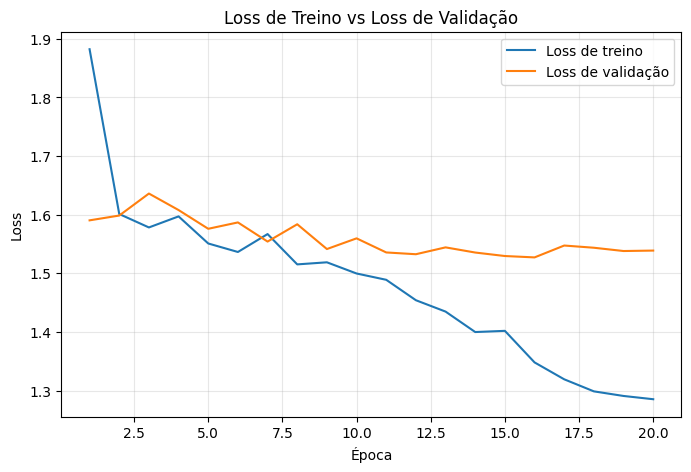

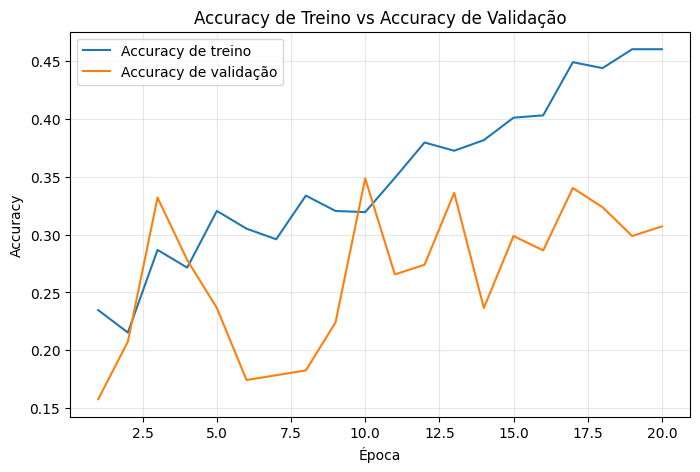

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(vit_history["epoch"], vit_history["train_loss"], label="Loss de treino")
plt.plot(vit_history["epoch"], vit_history["val_loss"], label="Loss de validação")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss de Treino vs Loss de Validação")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(vit_history["epoch"], vit_history["train_acc"], label="Accuracy de treino")
plt.plot(vit_history["epoch"], vit_history["val_acc"], label="Accuracy de validação")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Accuracy de Treino vs Accuracy de Validação")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 10. Avaliação


In [26]:
if CHECKPOINT_PATH.exists():
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    vit_model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Melhor checkpoint do ViT carregado da época {checkpoint['epoch']}")

vit_y_true, vit_y_pred, vit_probs = predict(vit_model, val_loader)
vit_metrics = compute_metrics(vit_y_true, vit_y_pred)

print(f"Accuracy: {vit_metrics['accuracy']:.4f}")
print(f"Macro precision: {vit_metrics['macro_precision']:.4f}")
print(f"Macro recall: {vit_metrics['macro_recall']:.4f}")
print(f"Macro F1: {vit_metrics['macro_f1']:.4f}")

display(metrics_table(vit_metrics))

print(
    classification_report(
        vit_y_true,
        vit_y_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
        zero_division=0,
    )
)


Melhor checkpoint do ViT carregado da época 17
Accuracy: 0.3402
Macro precision: 0.3316
Macro recall: 0.3543
Macro F1: 0.3245


,Classe,Precision,Recall,F1,Support
0,Sem Acidente,0.177778,0.470588,0.258065,17
1,Acidente Leve,0.366197,0.440678,0.400000,59
2,Acidente Moderado,0.469388,0.294872,0.362205,78
3,Acidente Severo,0.272727,0.225000,0.246575,40
4,Perda Total,0.372093,0.340426,0.355556,47
5,Macro,0.331637,0.354313,0.324480,241


                   precision    recall  f1-score   support

     Sem Acidente       0.18      0.47      0.26        17
    Acidente Leve       0.37      0.44      0.40        59
Acidente Moderado       0.47      0.29      0.36        78
  Acidente Severo       0.27      0.23      0.25        40
      Perda Total       0.37      0.34      0.36        47

         accuracy                           0.34       241
        macro avg       0.33      0.35      0.32       241
     weighted avg       0.37      0.34      0.34       241



## 11. Matriz de Confusão


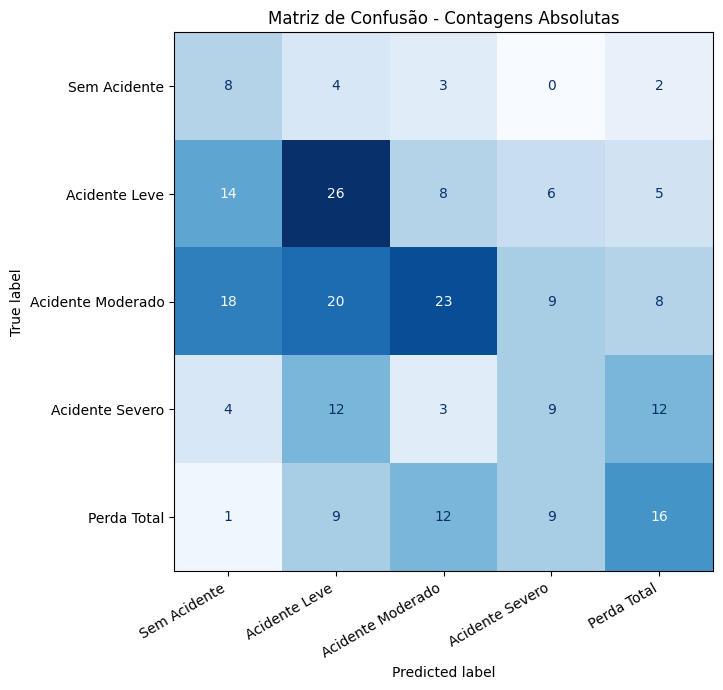

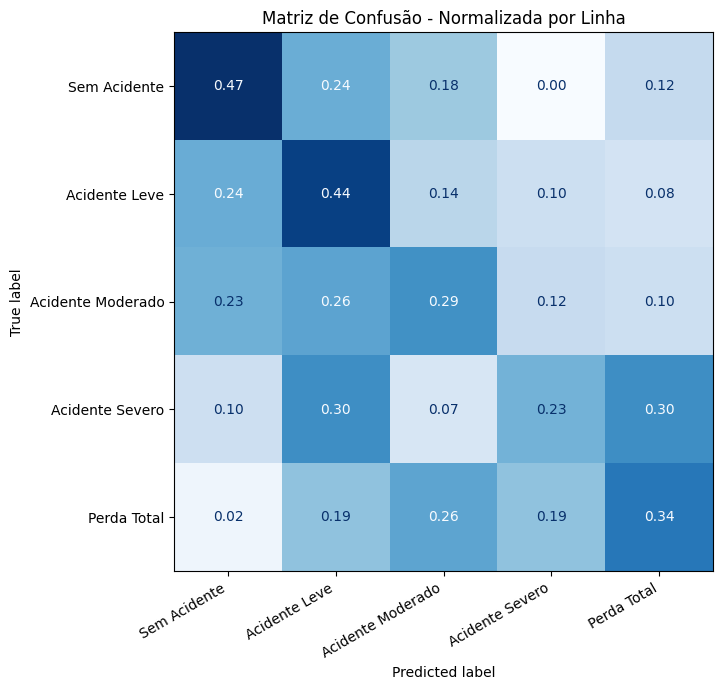

In [27]:
cm = confusion_matrix(vit_y_true, vit_y_pred, labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("Matriz de Confusão - Contagens Absolutas")
plt.xticks(rotation=30, ha="right")
plt.show()

cm_normalized = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
)
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
plt.title("Matriz de Confusão - Normalizada por Linha")
plt.xticks(rotation=30, ha="right")
plt.show()


## 12. Análise de Erros


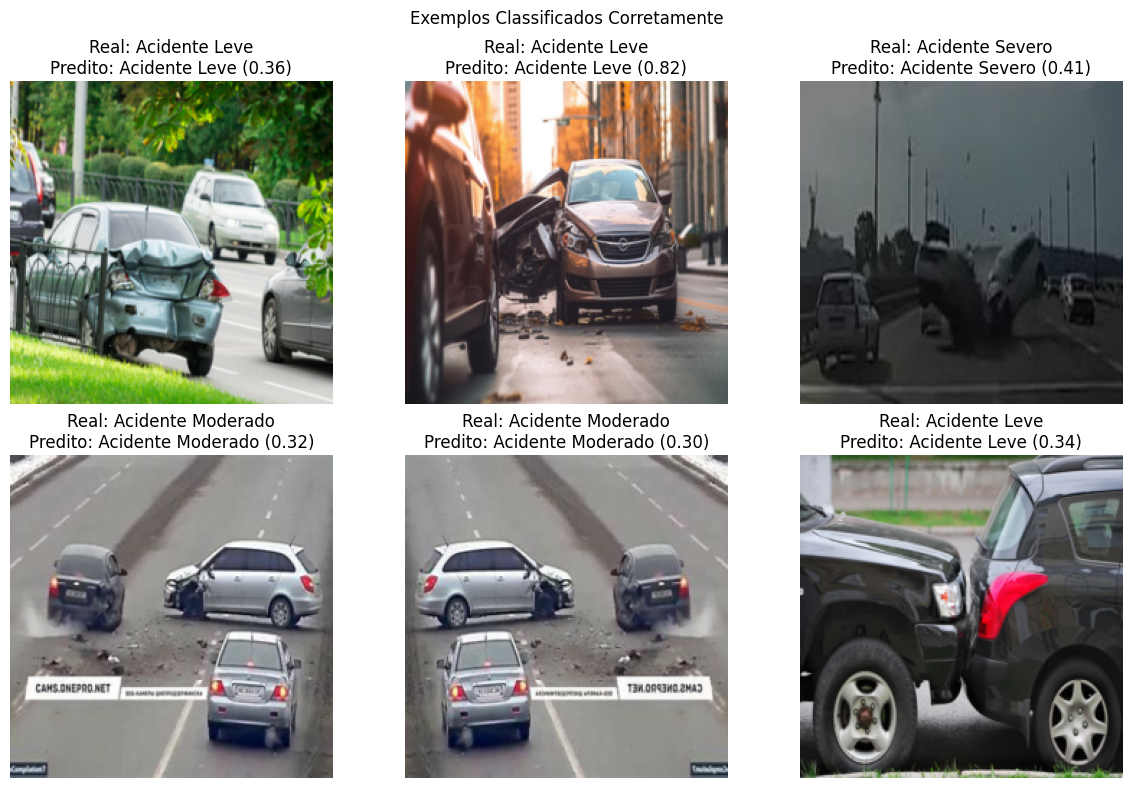

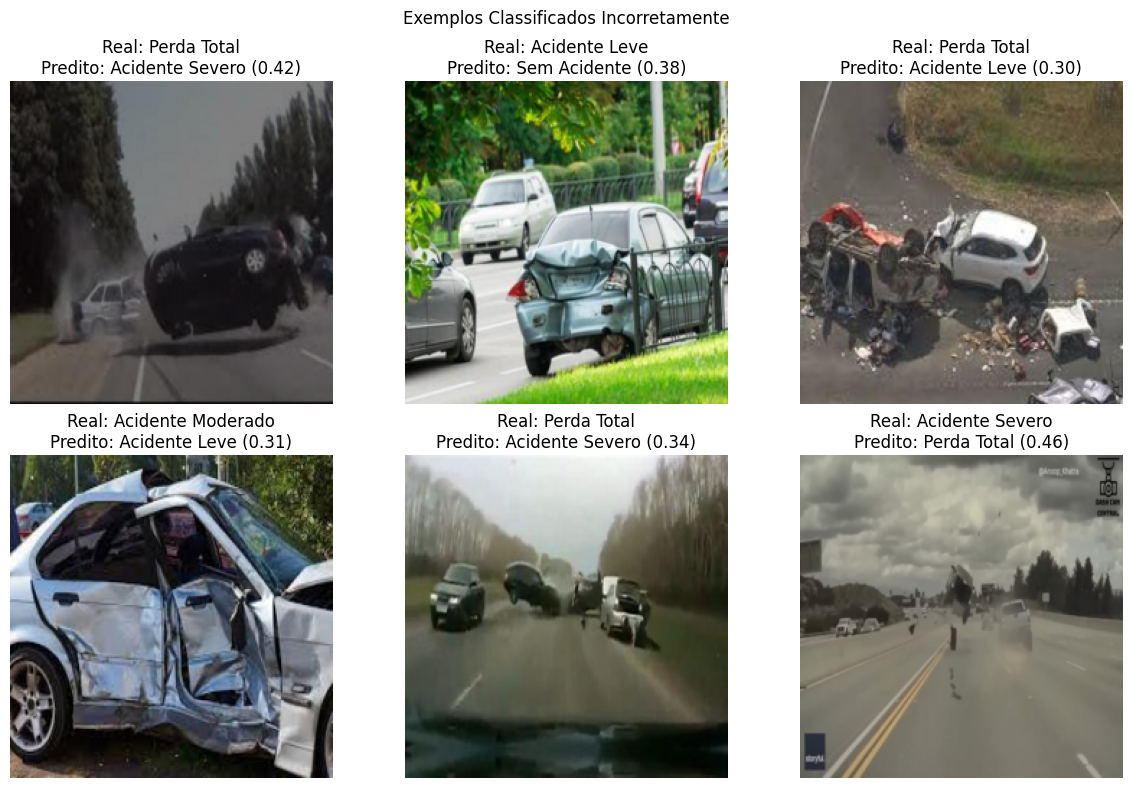

In [28]:
def denormalize_tensor(image_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    image = image_tensor.detach().cpu() * std + mean
    return image.clamp(0, 1)


@torch.no_grad()
def collect_validation_examples(model, dataset, max_items=None):
    model.eval()
    examples = []
    count = len(dataset) if max_items is None else min(len(dataset), max_items)

    for idx in range(count):
        image_tensor, label = dataset[idx]
        logits = model(image_tensor.unsqueeze(0).to(device))
        probs = logits.softmax(dim=1).squeeze(0).detach().cpu().numpy()
        pred = int(probs.argmax())
        examples.append(
            {
                "idx": idx,
                "image_tensor": image_tensor,
                "true": int(label),
                "pred": pred,
                "confidence": float(probs[pred]),
                "record": dataset.records[idx],
            }
        )
    return examples


def show_prediction_examples(examples, title, n=6):
    selected = examples[:n]
    if not selected:
        print(f"Nenhum exemplo para mostrar em: {title}")
        return

    cols = min(3, len(selected))
    rows = math.ceil(len(selected) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, example in zip(axes, selected):
        image = denormalize_tensor(example["image_tensor"]).permute(1, 2, 0).numpy()
        ax.imshow(image)
        ax.set_title(
            f"Real: {CLASS_NAMES[example['true']]}\n"
            f"Predito: {CLASS_NAMES[example['pred']]} ({example['confidence']:.2f})"
        )
        ax.axis("off")

    for ax in axes[len(selected):]:
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


val_examples = collect_validation_examples(vit_model, val_dataset)
correct_examples = [ex for ex in val_examples if ex["true"] == ex["pred"]]
incorrect_examples = [ex for ex in val_examples if ex["true"] != ex["pred"]]

show_prediction_examples(correct_examples, "Exemplos Classificados Corretamente", n=6)
show_prediction_examples(incorrect_examples, "Exemplos Classificados Incorretamente", n=6)


## Visualização de Bounding Boxes


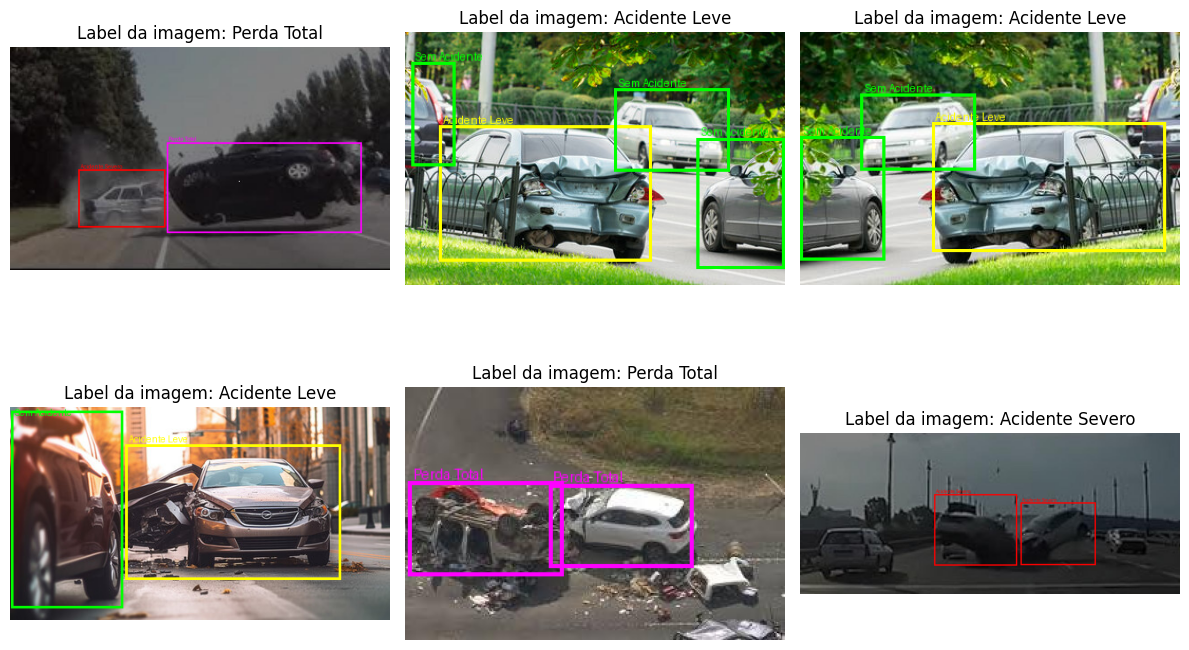

In [29]:
BOX_COLORS = {
    0: "lime",
    1: "yellow",
    2: "orange",
    3: "red",
    4: "magenta",
}


def read_yolo_boxes(label_path):
    boxes = []
    label_path = Path(label_path)
    if not label_path.exists():
        return boxes
    for line in label_path.read_text().splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        class_id = int(float(parts[0]))
        x_center, y_center, width, height = map(float, parts[1:5])
        boxes.append((class_id, x_center, y_center, width, height))
    return boxes


def draw_yolo_boxes(image, label_path):
    image = image.convert("RGB").copy()
    draw = ImageDraw.Draw(image)
    img_w, img_h = image.size

    for class_id, x_center, y_center, width, height in read_yolo_boxes(label_path):
        # Converte coordenadas YOLO normalizadas para pixels da imagem.
        x1 = (x_center - width / 2) * img_w
        y1 = (y_center - height / 2) * img_h
        x2 = (x_center + width / 2) * img_w
        y2 = (y_center + height / 2) * img_h

        color = BOX_COLORS.get(class_id, "white")
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        draw.text((x1 + 3, max(0, y1 - 12)), CLASS_NAMES.get(class_id, str(class_id)), fill=color)

    return image


def show_boxes(records, n=6):
    selected = records[:n]
    cols = min(3, len(selected))
    rows = math.ceil(len(selected) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, record in zip(axes, selected):
        image = Image.open(record["image_path"]).convert("RGB")
        boxed = draw_yolo_boxes(image, record["label_path"])
        ax.imshow(boxed)
        ax.set_title(f"Label da imagem: {CLASS_NAMES[record['label']]}")
        ax.axis("off")

    for ax in axes[len(selected):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_boxes(val_records, n=6)


## 13. Visualização de Attention


Shape da attention: (6, 197, 197)


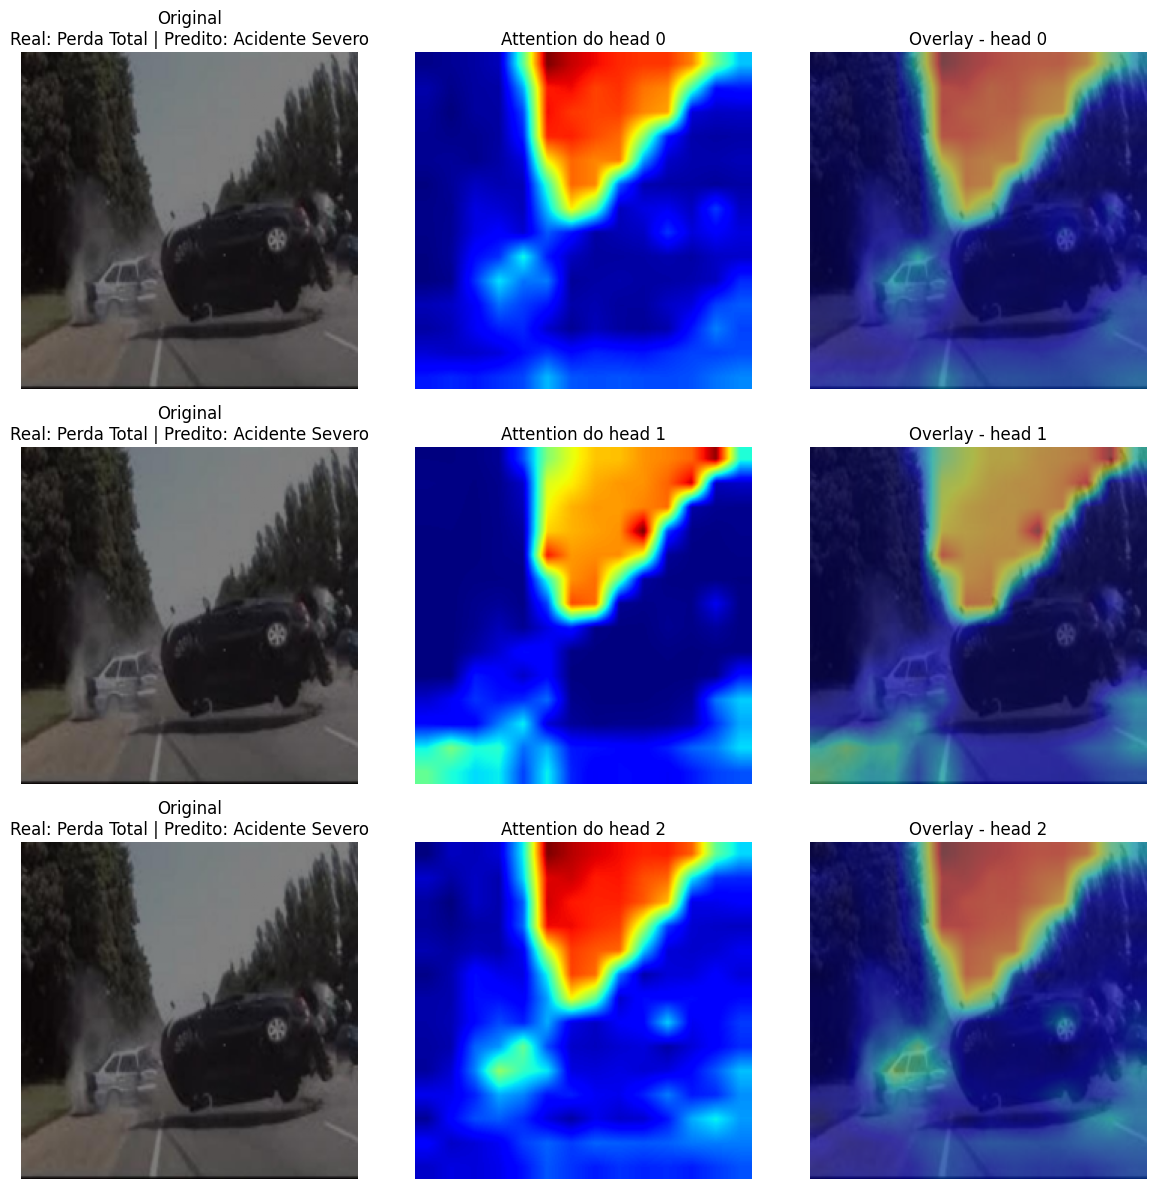

In [30]:
def get_attention_maps(model, image):
    """Retorna attention weights do último Transformer block para uma imagem."""
    model.eval()
    with torch.no_grad():
        if image.ndim == 3:
            image = image.unsqueeze(0)
        _ = model(image.to(device))
        attention = model.blocks[-1].attn.attn_weights
    if attention is None:
        raise RuntimeError("Nenhum attention weight foi capturado.")
    return attention[0].detach().cpu()


def attention_to_heatmap(attention, head_idx, grid_size):
    # Seleciona a atenção do CLS token para os patch tokens e remove o próprio CLS.
    cls_to_patches = attention[head_idx, 0, 1:]
    heatmap = cls_to_patches.reshape(grid_size, grid_size)
    heatmap = heatmap - heatmap.min()
    heatmap = heatmap / (heatmap.max() + 1e-8)
    return heatmap.numpy()


def overlay_heatmap(image_tensor, heatmap, alpha=0.45):
    image = denormalize_tensor(image_tensor).permute(1, 2, 0).numpy()
    heatmap_tensor = torch.tensor(heatmap, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    heatmap_resized = F.interpolate(
        heatmap_tensor,
        size=(IMAGE_SIZE, IMAGE_SIZE),
        mode="bilinear",
        align_corners=False,
    ).squeeze().numpy()

    cmap = plt.get_cmap("jet")
    heatmap_rgb = cmap(heatmap_resized)[..., :3]
    overlay = (1 - alpha) * image + alpha * heatmap_rgb
    return image, heatmap_resized, np.clip(overlay, 0, 1)


def show_attention_heads(model, dataset, index=0, heads=(0, 1, 2)):
    image_tensor, true_label = dataset[index]
    record = dataset.records[index]

    with torch.no_grad():
        logits = model(image_tensor.unsqueeze(0).to(device))
        pred = int(logits.argmax(dim=1).item())

    attention = get_attention_maps(model, image_tensor)
    print(f"Shape da attention: {tuple(attention.shape)}")

    grid_size = IMAGE_SIZE // PATCH_SIZE
    heads = [h for h in heads if h < attention.shape[0]]

    fig, axes = plt.subplots(len(heads), 3, figsize=(12, 4 * len(heads)))
    if len(heads) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, head_idx in enumerate(heads):
        heatmap = attention_to_heatmap(attention, head_idx, grid_size)
        image, heatmap_resized, overlay = overlay_heatmap(image_tensor, heatmap)

        axes[row, 0].imshow(image)
        axes[row, 0].set_title(
            f"Original\nReal: {CLASS_NAMES[true_label]} | Predito: {CLASS_NAMES[pred]}"
        )
        axes[row, 0].axis("off")

        axes[row, 1].imshow(heatmap_resized, cmap="jet")
        axes[row, 1].set_title(f"Attention do head {head_idx}")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title(f"Overlay - head {head_idx}")
        axes[row, 2].axis("off")

    plt.tight_layout()
    plt.show()

    return record


_ = show_attention_heads(vit_model, val_dataset, index=0, heads=(0, 1, 2))


## 14. Resumo dos Resultados


In [31]:
summary = {
    "Seed": SEED,
    "Dataset": str(DATASET_ROOT),
    "Amostras de treino": len(train_records),
    "Amostras de validação": len(val_records),
    "Grupos de treino": len(train_group_check),
    "Grupos de validação": len(val_group_check),
    "Image size": IMAGE_SIZE,
    "Patch size": PATCH_SIZE,
    "Embedding dimension": EMBED_DIM,
    "Transformer depth": DEPTH,
    "Attention heads": NUM_HEADS,
    "Batch size": BATCH_SIZE,
    "Learning rate": LEARNING_RATE,
    "Weight decay": WEIGHT_DECAY,
    "Épocas": NUM_EPOCHS,
    "Device": str(device),
    "Accuracy do baseline": baseline_metrics["accuracy"],
    "Macro F1 do baseline": baseline_metrics["macro_f1"],
    "Accuracy do ViT": vit_metrics["accuracy"],
    "Macro precision do ViT": vit_metrics["macro_precision"],
    "Macro recall do ViT": vit_metrics["macro_recall"],
    "Macro F1 do ViT": vit_metrics["macro_f1"],
    "Melhor checkpoint": str(CHECKPOINT_PATH),
}

for key, value in summary.items():
    print(f"{key}: {value}")

display(pd.DataFrame([summary]).T.rename(columns={0: "Valor"}))


Seed: 42
Dataset: /content/custom_dataset
Amostras de treino: 980
Amostras de validação: 241
Grupos de treino: 812
Grupos de validação: 204
Image size: 224
Patch size: 16
Embedding dimension: 384
Transformer depth: 6
Attention heads: 6
Batch size: 32
Learning rate: 0.0003
Weight decay: 0.05
Épocas: 20
Device: cuda
Accuracy do baseline: 0.5726141078838174
Macro F1 do baseline: 0.5619246744246744
Accuracy do ViT: 0.34024896265560167
Macro precision do ViT: 0.33163660239229936
Macro recall do ViT: 0.35431270563650025
Macro F1 do ViT: 0.32448002771195805
Melhor checkpoint: best_vit_cadd.pt


,Valor
Seed,42
Dataset,/content/custom_dataset
Amostras de treino,980
Amostras de validação,241
Grupos de treino,812
Grupos de validação,204
Image size,224
Patch size,16
Embedding dimension,384
Transformer depth,6
